<a href="https://colab.research.google.com/github/ilsagandeguay/PCVK-Ganjil-2026/blob/main/Week06/Week6_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODUL 6 – FILTER SPASIAL

## 1. Import Library dan Mount Google Drive

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BASE = '/content/drive/MyDrive/Politeknik Negeri Malang/Matakuliah/Pengenalan Citra dan Visi Komputer/Week6/Images/'

files = ['mandrill.tiff', 'lena.jpg', 'djawatan.jpg', 'macan.jpg']

img = cv.imread(BASE + files[0])
assert img is not None, f'Citra {files[0]} tidak ditemukan. Periksa BASE dan nama file.'

img2 = cv.imread(BASE + files[1])
assert img2 is not None, f'Citra {files[1]} tidak ditemukan. Periksa BASE dan nama file.'

img3 = cv.imread(BASE + files[2])
assert img3 is not None, f'Citra {files[2]} tidak ditemukan. Periksa BASE dan nama file.'

img4 = cv.imread(BASE + files[3])
assert img4 is not None, f'Citra {files[3]} tidak ditemukan. Periksa BASE dan nama file.'

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

img3_rgb = cv.cvtColor(img3, cv.COLOR_BGR2RGB)

img4_rgb = cv.cvtColor(img4, cv.COLOR_BGR2RGB)
img4_gray = cv.cvtColor(img4, cv.COLOR_BGR2GRAY)

print("Nama file :", files[0])
print("Ukuran    :", img.shape)

Nama file : mandrill.tiff
Ukuran    : (512, 512, 3)


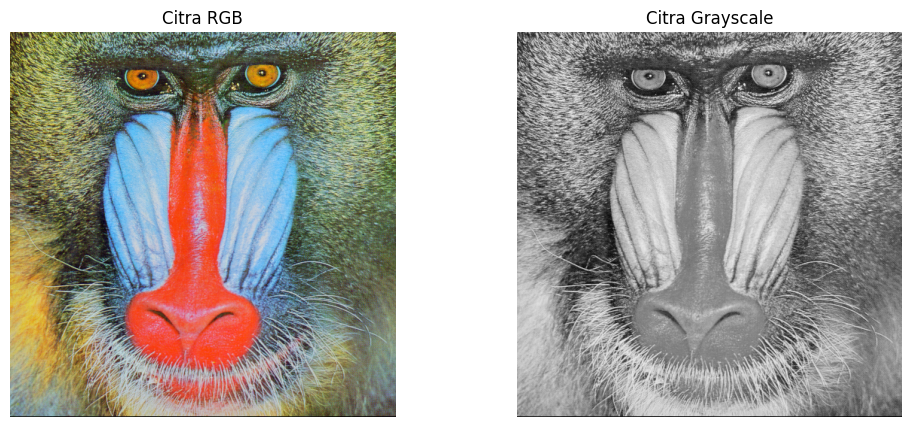

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra RGB')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Grayscale')
plt.axis('off')

plt.show()

# 2. PRAKTIKUM – FUNGSI KONVOLUSI MANUAL

In [ ]:
def konvolusi(image, kernel):
    image = image.astype(np.float32)
    kernel = np.array(kernel, dtype=np.float32)

    kh, kw = kernel.shape
    ih, iw = image.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode='constant',
        constant_values=0
    )

    output = np.zeros_like(image, dtype=np.float32)

    # Pembalikan kernel untuk operasi konvolusi
    kernel_flip = np.flip(kernel)

    for i in range(ih):
        for j in range(iw):
            region = padded[i:i + kh, j:j + kw]
            output[i, j] = np.sum(region * kernel_flip)

    output = np.clip(output, 0, 255)

    return output.astype(np.uint8)

### Sharpening

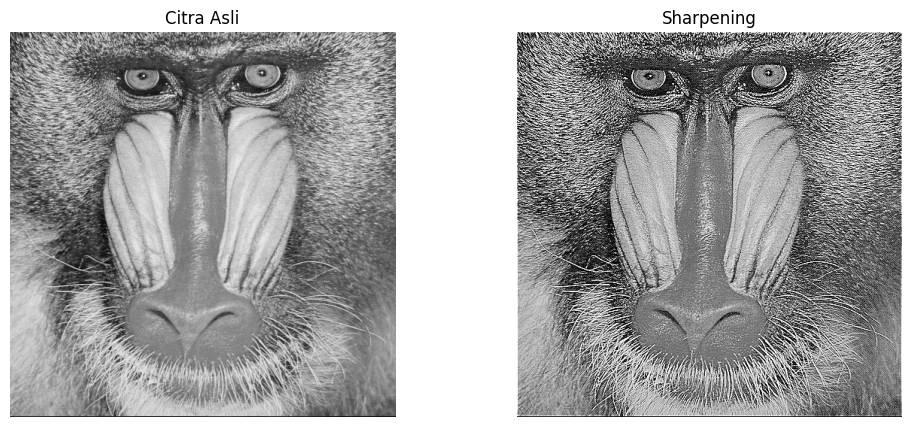

In [ ]:
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

hasil_sharpen = konvolusi(img_gray, kernel_sharpen)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title('Sharpening')
plt.axis('off')
plt.show()

# 3. Average Filter 3×3

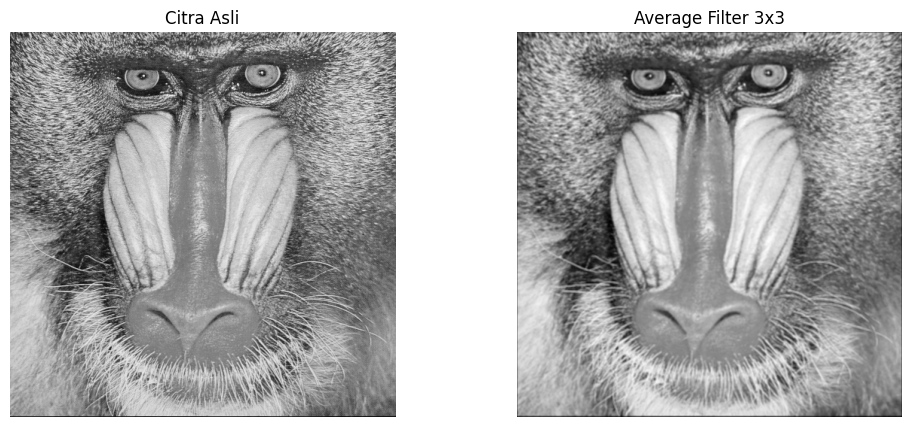

In [ ]:
kernel_average = np.ones((3, 3), dtype=np.float32) / 9
hasil_average = konvolusi(img_gray, kernel_average)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_average, cmap='gray')
plt.title('Average Filter 3x3')
plt.axis('off')
plt.show()

# 4. Low Pass Filter

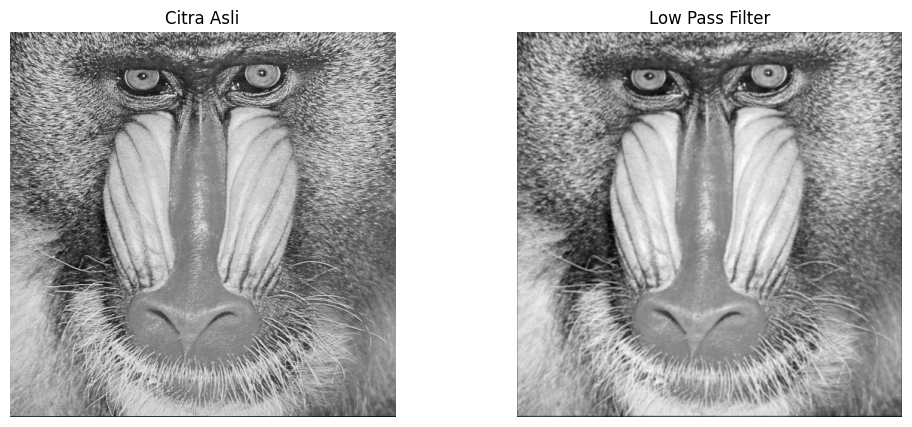

In [ ]:
kernel_lowpass = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
], dtype=np.float32) / 12

hasil_lowpass = konvolusi(img_gray, kernel_lowpass)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_lowpass, cmap='gray')
plt.title('Low Pass Filter')
plt.axis('off')
plt.show()

# 5. High Pass Filter

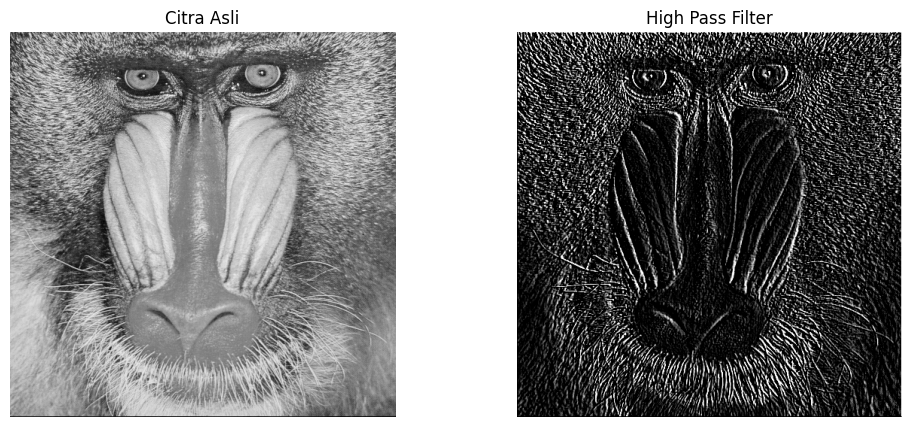

In [ ]:
kernel_highpass = np.array([
    [-1,  0,  1],
    [-1,  0,  3],
    [-3,  0,  1]
], dtype=np.float32)

hasil_highpass = konvolusi(img_gray, kernel_highpass)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_highpass, cmap='gray')
plt.title('High Pass Filter')
plt.axis('off')
plt.show()

# 6. Emboss

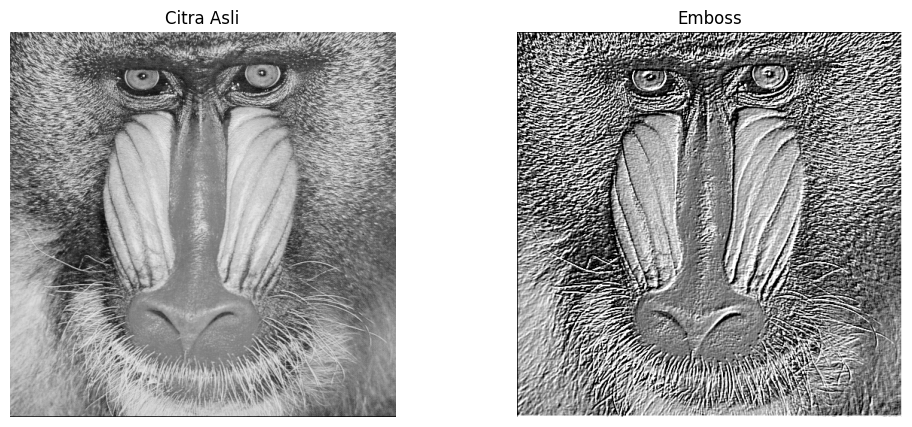

In [ ]:
kernel_emboss = np.array([
    [-2, -1,  0],
    [-1,  1,  1],
    [ 0,  1,  2]
], dtype=np.float32)

hasil_emboss = konvolusi(img_gray, kernel_emboss)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_emboss, cmap='gray')
plt.title('Emboss')
plt.axis('off')
plt.show()

# 7. Left Sobel Edge Detection

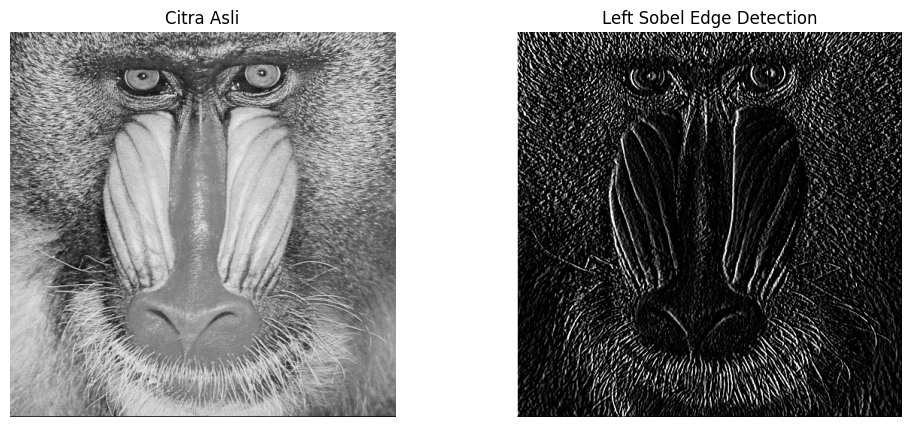

In [ ]:
kernel_sobel_left = np.array([
    [ 1,  0, -1],
    [ 2,  0, -2],
    [ 1,  0, -1]
], dtype=np.float32)

hasil_sobel = konvolusi(img_gray, kernel_sobel_left)
hasil_sobel = cv.convertScaleAbs(hasil_sobel)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_sobel, cmap='gray')
plt.title('Left Sobel Edge Detection')
plt.axis('off')
plt.show()

# 8. Edge Detection

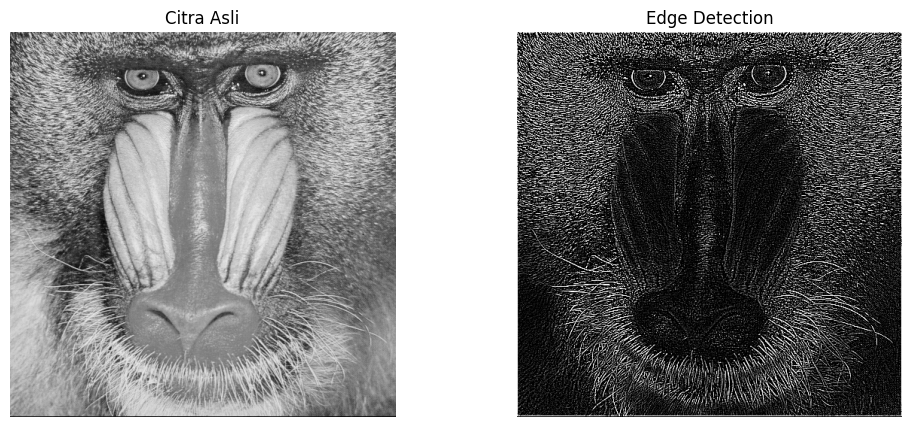

In [ ]:
kernel_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

hasil_edge = konvolusi(img_gray, kernel_edge)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_edge, cmap='gray')
plt.title('Edge Detection')
plt.axis('off')
plt.show()

# 9. Gaussian Blur 21×21

In [ ]:
kernel_size = 21
sigma = math.sqrt(kernel_size)

gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
gaussian_kernel = gaussian_1d @ gaussian_1d.T

print("Ukuran kernel:", gaussian_kernel.shape)
print("Jumlah kernel :", gaussian_kernel.sum())

Ukuran kernel: (21, 21)
Jumlah kernel : 1.0


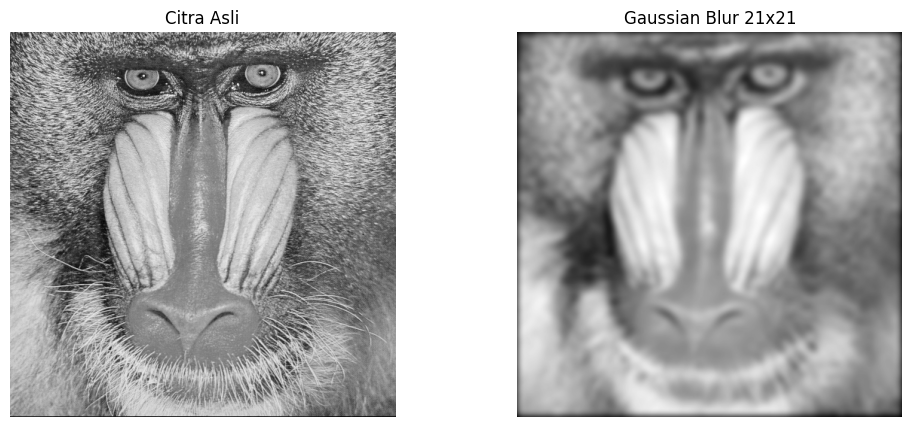

In [ ]:
hasil_gaussian = konvolusi(img_gray, gaussian_kernel)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_gaussian, cmap='gray')
plt.title('Gaussian Blur 21x21')
plt.axis('off')
plt.show()

# 10. Filter Library dan Filter Modern

## Citra Asli

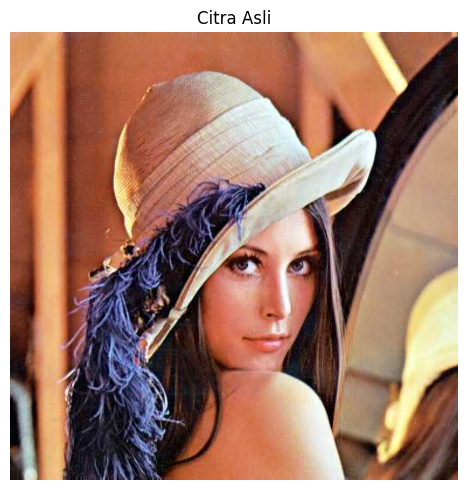

In [ ]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (im, title) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        if im.ndim == 2:
            plt.imshow(im, cmap='gray')
        else:
            plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_side_by_side([img2], ['Citra Asli'])

## Percobaan 1 — Gaussian, Sharpen, dan Canny dengan filter 2D

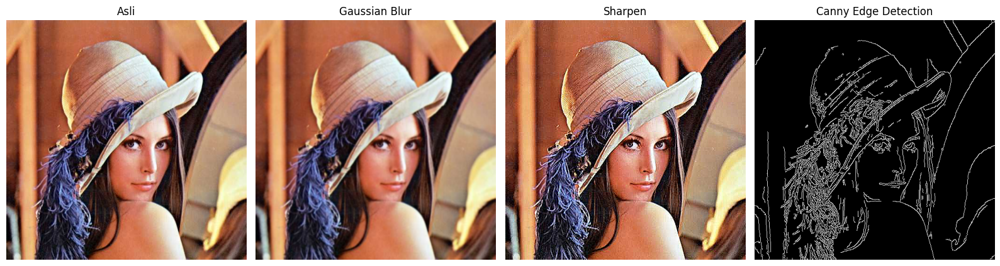

In [ ]:
blur = cv.GaussianBlur(img2, (7, 7), 1)

sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]], dtype=np.float32)
sharpen = cv.filter2D(img2, -1, sharpen_kernel)

gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
edges = cv.Canny(gray, 100, 200)

show_side_by_side([img2, blur, sharpen, edges],
                  ['Asli', 'Gaussian Blur', 'Sharpen', 'Canny Edge Detection'],
                  figsize=(16, 5))

## Percobaan 2 — Bilateral Filter dan Edge Preserving Filter

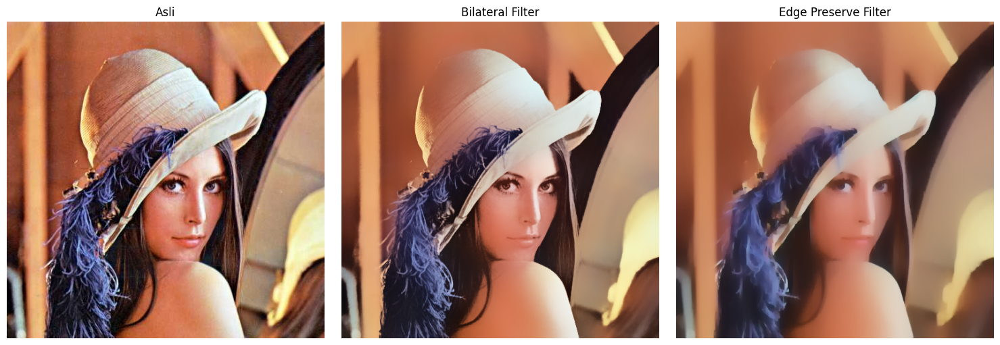

In [ ]:
bilateral = cv.bilateralFilter(img2, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(img2, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img2, bilateral, edge_preserve],
                  ['Asli', 'Bilateral Filter', 'Edge Preserve Filter'],
                  figsize=(15, 5))

## Percobaan 3 — CNN Feature Map

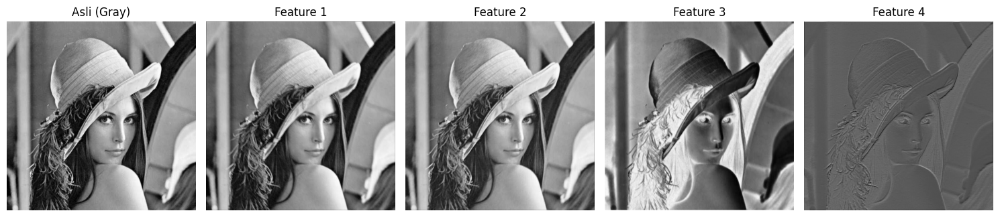

In [ ]:
torch.manual_seed(42)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()
gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
img_tensor = torch.tensor(gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
    features = model(img_tensor)

feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
plt.figure(figsize=(15, 4))
plt.subplot(1, len(feature_maps) + 1, 1)
plt.imshow(gray, cmap='gray')
plt.title('Asli (Gray)')
plt.axis('off')
for i, fmap in enumerate(feature_maps, 2):
    plt.subplot(1, len(feature_maps) + 1, i)
    plt.imshow(fmap, cmap='gray')
    plt.title(f'Feature {i-1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Percobaan 4 — Beauty dan Old/Vintage Filter

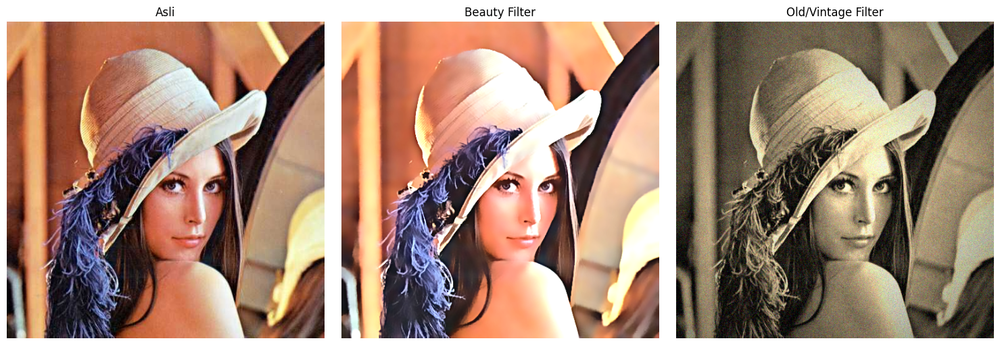

In [ ]:
# Beauty Filter: bilateral smoothing, unsharp mask, brightness/contrast
smooth = cv.bilateralFilter(img2, d=15, sigmaColor=75, sigmaSpace=75)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
beauty = cv.convertScaleAbs(sharpened, alpha=1.2, beta=15)

# Vintage Filter: sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]], dtype=np.float32)
sepia = cv.transform(img2, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Vignette
rows, cols = img2.shape[:2]
kx = cv.getGaussianKernel(cols, cols * 0.6)
ky = cv.getGaussianKernel(rows, rows * 0.6)
mask = (ky @ kx.T)
mask = mask / mask.max()
vintage = sepia.astype(np.float32)
for ch in range(3):
    vintage[:, :, ch] *= mask

# Grain/noise
rng = np.random.default_rng(42)
noise = rng.normal(0, 15, vintage.shape)
vintage = np.clip(vintage + noise, 0, 255).astype(np.uint8)

show_side_by_side([img2, beauty, vintage],
                  ['Asli', 'Beauty Filter', 'Old/Vintage Filter'],
                  figsize=(15, 5))

## Percobaan 5 — Anime / Cartoon Filter

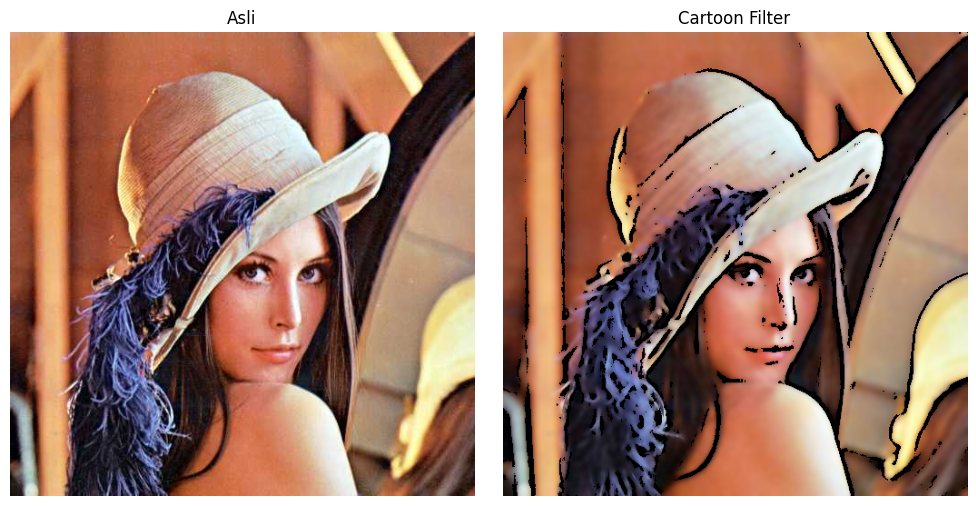

In [ ]:
gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)
color = cv.bilateralFilter(img2, d=9, sigmaColor=200, sigmaSpace=200)
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img2, cartoon], ['Asli', 'Cartoon Filter'], figsize=(10, 5))

## Percobaan 6 — Night Filter

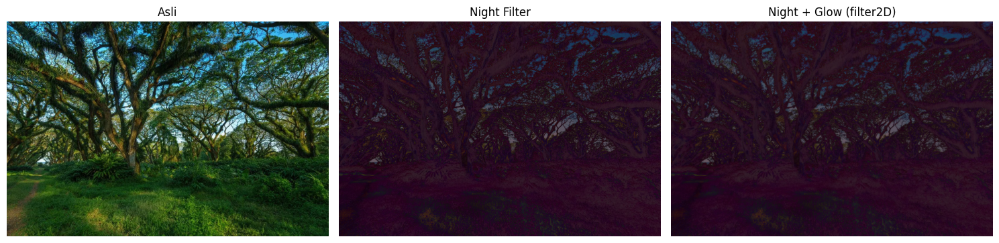

In [ ]:
night = cv.convertScaleAbs(img3, alpha=0.6, beta=-40)

# Citra OpenCV menggunakan urutan kanal BGR
blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

g = cv.getGaussianKernel(15, 2)
glow_kernel = (g @ g.T).astype(np.float32)
glow = cv.filter2D(night, -1, glow_kernel)
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img3, night, night_glow],
                  ['Asli', 'Night Filter', 'Night + Glow (filter2D)'],
                  figsize=(15, 5))

## Percobaan 7 — Filter Pagi dan Pagi + Kabut

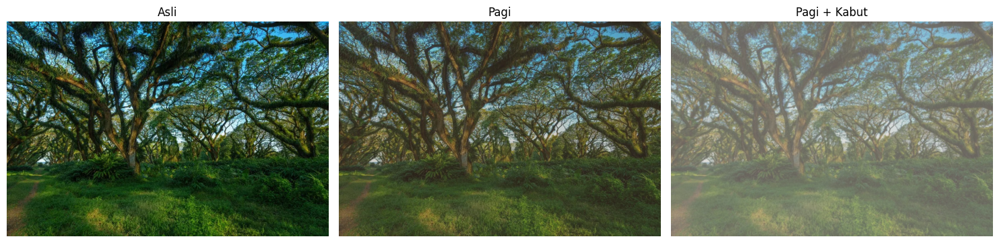

In [ ]:
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img3, alpha=alpha, beta=beta)

warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

g = cv.getGaussianKernel(3, 1)
kernel = g @ g.T
kabut = cv.filter2D(pagi, -1, kernel)
white_layer = np.full_like(kabut, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img3, pagi, kabut],
                  ['Asli', 'Pagi', 'Pagi + Kabut'],
                  figsize=(15, 5))

# 11. TUGAS 1 – Mean Filter vs Median Filter pada Salt and Pepper Noise

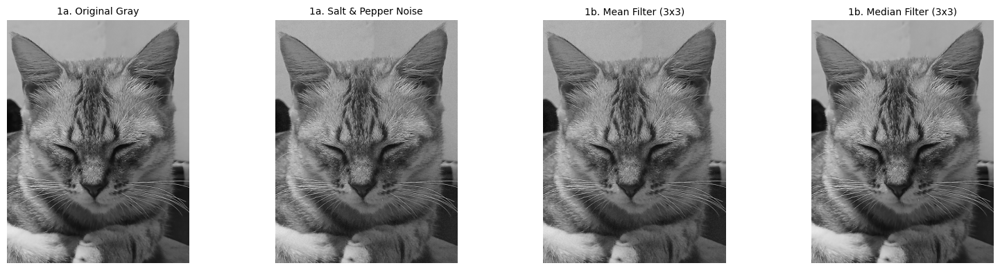

In [6]:
# ==============================================================================
# NOMOR 1: Salt & Pepper Noise Filtering
# ==============================================================================

# a. Menambahkan Salt and Pepper Noise
def add_salt_and_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03):
    noisy_img = np.copy(image)
    # Salt (Piksel Putih = 255)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_img[tuple(coords)] = 255

    # Pepper (Piksel Hitam = 0)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_img[tuple(coords)] = 0
    return noisy_img

np.random.seed(42)
img_noisy = add_salt_and_pepper_noise(img4_gray)

# b. Terapkan Mean Filter (3x3) dan Median Filter (3x3)
img_mean = cv.blur(img_noisy, (3, 3))         # Mean Filter 3x3
img_median = cv.medianBlur(img_noisy, 3)     # Median Filter 3x3

# Tampilkan Hasil
titles = ["1a. Original Gray", "1a. Salt & Pepper Noise", "1b. Mean Filter (3x3)", "1b. Median Filter (3x3)"]
images = [img4_gray, img_noisy, img_mean, img_median]

plt.figure(figsize=(16, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 12. TUGAS 2 – Pemilihan Ukuran Kernel Sharpening

In [ ]:
# Membuat citra sedikit buram
img_blur = cv.GaussianBlur(
    img4_gray,
    (9, 9),
    0
)

# Sharpening 3x3
kernel_sharp_3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

sharp_3 = konvolusi(img_blur, kernel_sharp_3)

# Sharpening 5x5
kernel_sharp_5 = np.array([
    [ 0,  0, -1,  0,  0],
    [ 0, -1, -1, -1,  0],
    [-1, -1, 13, -1, -1],
    [ 0, -1, -1, -1,  0],
    [ 0,  0, -1,  0,  0]
], dtype=np.float32)

sharp_5 = konvolusi(img_blur, kernel_sharp_5)

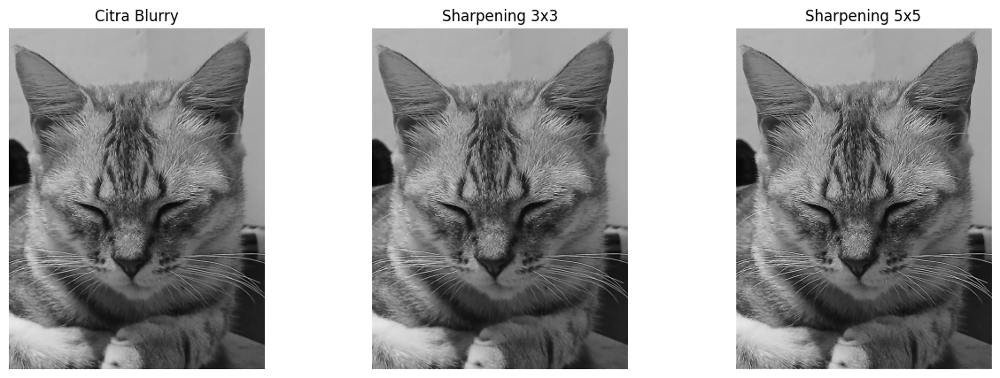

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_blur, cmap='gray')
plt.title('Citra Blurry')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharp_3, cmap='gray')
plt.title('Sharpening 3x3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharp_5, cmap='gray')
plt.title('Sharpening 5x5')
plt.axis('off')

plt.show()

In [ ]:
def edge_strength(image):
    gx = cv.Sobel(image, cv.CV_64F, 1, 0, ksize=3)
    gy = cv.Sobel(image, cv.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(gx**2 + gy**2)

    return magnitude.mean()

edge_blur = edge_strength(img_blur)
edge_3 = edge_strength(sharp_3)
edge_5 = edge_strength(sharp_5)

print("Rata-rata kekuatan tepi")
print("------------------------")
print(f"Citra blurry : {edge_blur:.4f}")
print(f"Sharpen 3x3  : {edge_3:.4f}")
print(f"Sharpen 5x5  : {edge_5:.4f}")

Rata-rata kekuatan tepi
------------------------
Citra blurry : 20.6740
Sharpen 3x3  : 24.5449
Sharpen 5x5  : 44.3446


# 13. TUGAS 3 – Filter Kartun Sederhana

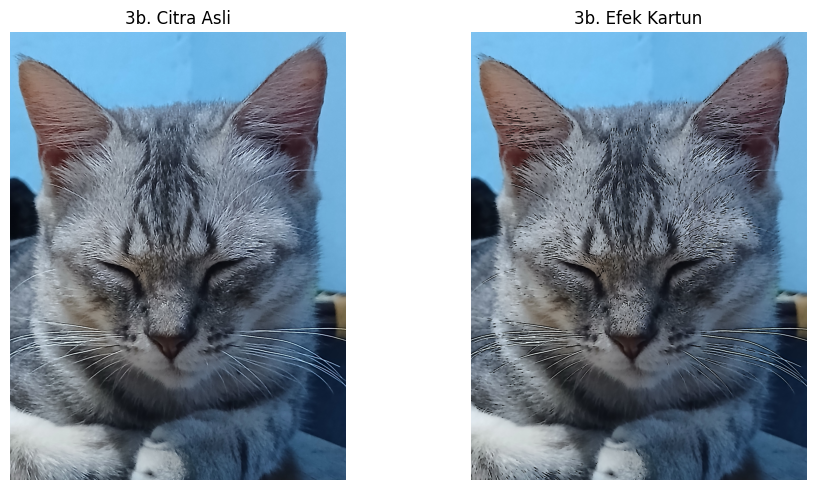

In [ ]:
# a. Buat fungsi kustom kartun(image)
def kartun(image):
    # 1. Penghalusan warna menggunakan Bilateral Filter
    color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=250, sigmaSpace=250)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray_img = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray_img, 7)
    edges = cv.adaptiveThreshold(
        gray_blur, 255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        blockSize=9,
        C=9
    )

    # Konversi edges ke 3 channel (BGR)
    edges_bgr = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # 3. Penggabungan (kombinasi) menggunakan operasi bitwise AND
    cartoon_img = cv.bitwise_and(color_smooth, edges_bgr)
    return cartoon_img

# b. Terapkan fungsi dan tampilkan bersebelahan
img_cartoon_result = kartun(img4)

# Tampilkan Hasil (Ubah BGR ke RGB untuk Matplotlib)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img4, cv.COLOR_BGR2RGB))
plt.title("3b. Citra Asli")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_cartoon_result, cv.COLOR_BGR2RGB))
plt.title("3b. Efek Kartun")
plt.axis('off')

plt.tight_layout()
plt.show()

# 14. Perbandingan Hasil Filter

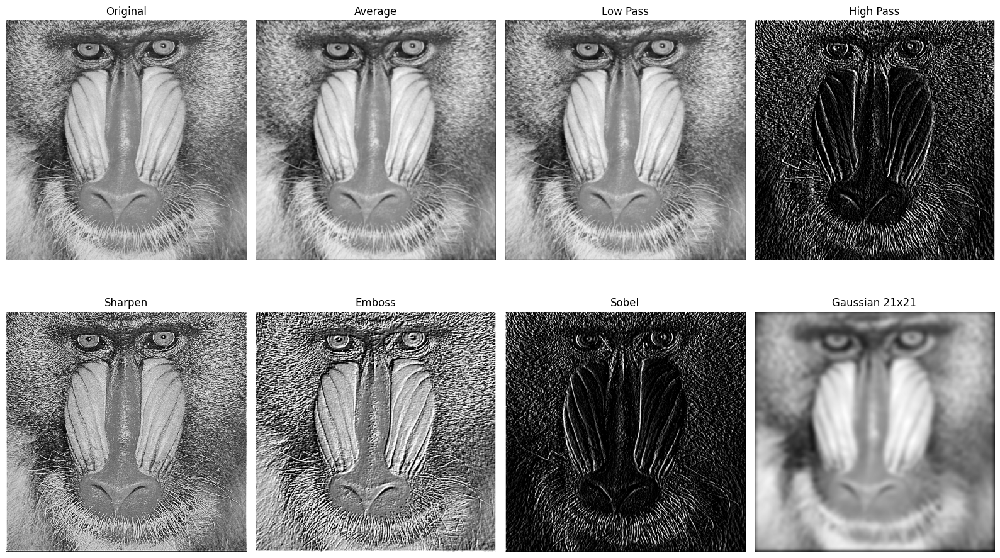

In [ ]:
plt.figure(figsize=(16, 10))

results = [
    (img_gray, 'Original'),
    (hasil_average, 'Average'),
    (hasil_lowpass, 'Low Pass'),
    (hasil_highpass, 'High Pass'),
    (hasil_sharpen, 'Sharpen'),
    (hasil_emboss, 'Emboss'),
    (hasil_sobel, 'Sobel'),
    (hasil_gaussian, 'Gaussian 21x21')
]

for i, (result, title) in enumerate(results, 1):
    plt.subplot(2, 4, i)
    plt.imshow(result, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()